***Sistema Inteligente de Diagnóstico de la Calidad del Café***
---



## 📋 Información General

**Asignatura:** Inteligencia Artificial  
**Docente:** Jaime Alberto Guzmán Luna  
**Universidad:** Nacional de Colombia

---

## 🔧 Equipo

**Grupo:** 01,
**Equipo de trabajo:** 11

---

## 👨‍🎓 Integrantes

- Raphael Herve Marie De Vathaire
- Efrain Alberto Diaz Caro
- Sebastían Cano Olarte
- Michael Garcia Quincos

---


INSTALACIÓN DE LIBRERÍAS

In [ ]:
!pip install rdflib
!pip install owlrl
!pip install scikit-fuzzy
!pip install matplotlib
!pip install experta
!pip install pandas

In [ ]:
# Para compatibilidad con versiones anteriores, siempre utilizarlo.
import collections.abc
if not hasattr(collections, 'Mapping'):
    collections.Mapping = collections.abc.Mapping

IMPORTAR LIBRERIAS

In [ ]:
from rdflib import Graph, Namespace, RDF, RDFS, XSD, Literal
from rdflib.namespace import FOAF, DC
from owlrl import DeductiveClosure, RDFS_Semantics
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from rdflib import Graph, Namespace, RDF, XSD
import pandas as pd # Importar pandas para guardar en CSV
from experta import *
from rdflib import Graph, Namespace, RDF
import pandas as pd
from pathlib import Path

**Ontología:** Representación del Conocimiento para la Calidad del Café

In [ ]:

EX = Namespace("http://example.org/cafe#")

g = Graph()
# Bindings para que el Turtle resultante tenga prefijos legibles
g.bind("ex", EX)
g.bind("foaf", FOAF)
g.bind("dc", DC)
g.bind("xsd", XSD)
g.bind("rdfs", RDFS)
g.bind("rdf", RDF)

#CLASES
classes = [
    "Cafe", "CafeExportacion", "CafeLocal", "CafeDesecho", "Lote",
    "SubLote", "Mercado", "Cliente", "Puerto", "Defecto", "PropiedadSensorial"
]
for c in classes:
    g.add((EX[c], RDF.type, RDFS.Class))

#JERARQUÍAS(subClassOf)
g.add((EX.CafeExportacion, RDFS.subClassOf, EX.Cafe))
g.add((EX.CafeLocal, RDFS.subClassOf, EX.Cafe))
g.add((EX.CafeDesecho, RDFS.subClassOf, EX.Cafe))
g.add((EX.Cliente, RDFS.subClassOf, FOAF.Agent))   # vocabulario externo
g.add((EX.Puerto, RDFS.subClassOf, EX.Mercado))
g.add((EX.SubLote, RDFS.subClassOf, EX.Lote))

#PROPIEDADES con domain/range
props = [
    ("tamañoGrano", EX.SubLote, XSD.float),
    ("tieneDestino", EX.SubLote, EX.Mercado),
    ("relacionadoCon", None, None),  # super-prop
    ("nivelHumedad", EX.Lote, XSD.integer),
    ("tieneCalidad", EX.SubLote, EX.PropiedadSensorial),
    ("presentaDefecto", EX.SubLote, EX.Defecto),
    ("solicitadoPor", EX.Mercado, EX.Cliente),
    ("exportadoDesde", EX.SubLote, EX.Puerto),
    ("destinoInternacional", EX.Mercado, XSD.boolean),
    ("fechaContrato", EX.SubLote, XSD.date),
    ("perteneceALote", EX.SubLote, EX.Lote),
    ("tieneOrigen", EX.SubLote, EX.Cafe),  # propiedad extra para ligar SubLote -> Cafe
]
for name, dom, ran in props:
    p = EX[name]
    g.add((p, RDF.type, RDF.Property))
    if dom is not None:
        g.add((p, RDFS.domain, dom))
    if ran is not None:
        g.add((p, RDFS.range, ran))

# subPropertyOf: tieneDestino -> relacionadoCon
g.add((EX.tieneDestino, RDFS.subPropertyOf, EX.relacionadoCon))

# usar DC como propiedad externa para títulos
g.add((DC.title, RDF.type, RDF.Property))

#INDIVIDUOS: >=4 individuos por clase (explícito)
# Lotes (4)
for i in range(1, 5):
    li = EX[f"Lote{i}"]
    g.add((li, RDF.type, EX.Lote))
    g.add((li, EX.nivelHumedad, Literal(10 + i, datatype=XSD.integer)))
    g.add((li, DC.title, Literal(f"Lote #{i}", datatype=XSD.string)))

# SubLotes (8)
sublotes = [
    ("SubLote1a", "Lote1", "MercadoInternacional", "AltoAroma", None, "PuertoBuenaventura", "2025-09-01", "CafeExport1"),
    ("SubLote1b", "Lote1", "MercadoNacional1", "AltaAcidez", None, "PuertoCartagena", "2025-09-02", "CafeLocal1"),
    ("SubLote1c", "Lote1", "MercadoNacional2", None, "DefectoMoho", "PuertoHamburgo", "2025-09-03", "CafeDesecho1"),
    ("SubLote2a", "Lote2", "MercadoNacional3", "Equilibrado", None, "PuertoRotterdam", "2025-09-05", "CafeExport2"),
    ("SubLote2b", "Lote2", "MercadoInternacional", "AltoAroma", None, "PuertoBuenaventura", "2025-09-06", "CafeExport3"),
    ("SubLote3a", "Lote3", "MercadoNacional1", "BajoCuerpo", "DefectoNegro", "PuertoCartagena", "2025-09-10", "CafeLocal2"),
    ("SubLote3b", "Lote3", "MercadoInternacional", "AltaAcidez", None, "PuertoRotterdam", "2025-09-12", "CafeExport4"),
    ("SubLote4a", "Lote4", "MercadoNacional2", None, "DefectoPartido", "PuertoHamburgo", "2025-09-15", "CafeDesecho2"),
]
for s, lote, destino, calidad, defecto, puerto, fecha, cafe_origen in sublotes:
    g.add((EX[s], RDF.type, EX.SubLote))
    g.add((EX[s], EX.perteneceALote, EX[lote]))
    g.add((EX[s], EX.tieneDestino, EX[f"Mercado{destino.replace('Mercado','')}"] if destino.startswith("Mercado") else EX[f"Mercado{destino}"]))  # se usan nombres consistentes abajo
    if calidad:
        g.add((EX[s], EX.tieneCalidad, EX[calidad]))
    if defecto:
        g.add((EX[s], EX.presentaDefecto, EX[f"Defecto{defecto.replace('Defecto','')}"] if defecto else EX[defecto]))
    g.add((EX[s], EX.exportadoDesde, EX[puerto]))
    g.add((EX[s], EX.fechaContrato, Literal(fecha, datatype=XSD.date)))
    # ligar al Cafe (propiedad que creamos)
    g.add((EX[s], EX.tieneOrigen, EX[cafe_origen]))

# Mercados (crear 4 con nombres consistentes)
for name in ["Internacional", "Nacional1", "Nacional2", "Nacional3"]:
    g.add((EX[f"Mercado{name}"], RDF.type, EX.Mercado))

# Clientes (4)
clientes = ["ExportadoraCafeSA", "Tostao", "NescafeColombia", "JuanValdez"]
for c in clientes:
    g.add((EX[c], RDF.type, EX.Cliente))
    g.add((EX[c], FOAF.name, Literal(c, datatype=XSD.string)))

# Puertos (4)
for p in ["PuertoBuenaventura", "PuertoCartagena", "PuertoRotterdam", "PuertoHamburgo"]:
    g.add((EX[p], RDF.type, EX.Puerto))

# Defectos (>=4)
for d in ["Moho", "Negro", "Partido", "Broca"]:
    g.add((EX[f"Defecto{d}"], RDF.type, EX.Defecto))

# Propiedades sensoriales (>=4)
for ps in ["AltoAroma", "AltaAcidez", "Equilibrado", "BajoCuerpo"]:
    g.add((EX[ps], RDF.type, EX.PropiedadSensorial))

# Cafes: crear 4 individuos para cada subclase y 4 para Cafe
for i in range(1, 5):
    g.add((EX[f"Cafe{i}"], RDF.type, EX.Cafe))
    g.add((EX[f"CafeExport{i}"], RDF.type, EX.CafeExportacion))
    g.add((EX[f"CafeLocal{i}"], RDF.type, EX.CafeLocal))
    g.add((EX[f"CafeDesecho{i}"], RDF.type, EX.CafeDesecho))

#Enlaces adicionales Mercado -> Cliente
g.add((EX.MercadoInternacional, EX.solicitadoPor, EX.ExportadoraCafeSA))
g.add((EX.MercadoNacional1, EX.solicitadoPor, EX.Tostao))
g.add((EX.MercadoNacional2, EX.solicitadoPor, EX.JuanValdez))
g.add((EX.MercadoNacional3, EX.solicitadoPor, EX.NescafeColombia))

#EJEMPLOS para demostrar los 3 casos de razonamiento
# Crear un recurso sin tipo y darle una propiedad con domain = SubLote (caso 2)
S_sin_tipo = EX["SubloteSinTipo1"]
g.add((S_sin_tipo, EX.perteneceALote, EX.Lote1))  # como perteneceALote tiene domain SubLote, el razonador debe inferir rdf:type SubLote

# Otro recurso sin tipo que usa tieneDestino (para demostrar subProperty también)
S_sin_tipo2 = EX["SubloteSinTipo2"]
g.add((S_sin_tipo2, EX.tieneDestino, EX.MercadoInternacional))
# no se le añade rdf:type explícito: el razonador debería inferir:
#  - (S_sin_tipo2 rdf:type ex:SubLote)  (domain)
#  - (S_sin_tipo2 ex:relacionadoCon ex:MercadoInternacional)  (por subPropertyOf)

#SERIALIZAR ANTES del razonamiento (para comparar)
pre_triples = set(g)
g_before = Graph()
# Bind same prefixes para el archivo antes
g_before.bind("ex", EX); g_before.bind("foaf", FOAF); g_before.bind("dc", DC)
g_before.bind("xsd", XSD); g_before.bind("rdfs", RDFS); g_before.bind("rdf", RDF)
for t in pre_triples:
    g_before.add(t)
g_before.serialize("ontologia_before_reasoning.ttl", format="turtle")

#APLICAR RAZONAMIENTO RDFS (OWL-RL)
closure = DeductiveClosure(RDFS_Semantics)
closure.expand(g)

#comparar y listar triples inferidos (nuevos hechos)
post_triples = set(g)
new_triples = post_triples - pre_triples

print("Triples antes:", len(pre_triples))
print("Triples después:", len(post_triples))
print("Nuevos triples inferidos:", len(new_triples))
print("\nEjemplos de triples inferidos (hasta 20):")
count = 0
for s, p, o in sorted(new_triples, key=lambda x: (str(x[1]), str(x[0]), str(x[2])))[:20]:
    print(s.n3(), p.n3(), o.n3())
    count += 1

#buscar y mostrar ejemplos específicos para los 3 casos
print("\n--- Ejemplos por caso ---")

# Caso 1: jerarquía -> SubLote -> Lote (cada SubLote debería obtener rdf:type ex:Lote)
for s in ["SubLote1a", "SubLote2a", "SubLote3b", "SubLote4a"]:
    triple = (EX[s], RDF.type, EX.Lote)
    print("Caso 1 (jerarquía) - triple inferido?", triple in new_triples, "->", triple)

# Caso 2: inferencia por domain/range (recurso sin tipo que usamos perteneceALote)
triple_case2 = (S_sin_tipo, RDF.type, EX.SubLote)
print("Caso 2 (domain) - se infirió tipo SubLote para SubloteSinTipo1?:", triple_case2 in new_triples, "->", triple_case2)

# Caso 3: subProperty -> tieneDestino subPropertyOf relacionadoCon
triple_case3 = (S_sin_tipo2, EX.relacionadoCon, EX.MercadoInternacional)
print("Caso 3 (subProperty) - se infirió relacionadoCon para SubloteSinTipo2?:", triple_case3 in new_triples, "->", triple_case3)

# Guardar grafo final (después del razonador)
g.serialize("ontologia_after_reasoning.ttl", format="turtle")


Triples antes: 168
Triples después: 369
Nuevos triples inferidos: 201

Ejemplos de triples inferidos (hasta 20):
<http://example.org/cafe#SubLote1a> <http://example.org/cafe#relacionadoCon> <http://example.org/cafe#MercadoInternacional>
<http://example.org/cafe#SubLote1b> <http://example.org/cafe#relacionadoCon> <http://example.org/cafe#MercadoNacional1>
<http://example.org/cafe#SubLote1c> <http://example.org/cafe#relacionadoCon> <http://example.org/cafe#MercadoNacional2>
<http://example.org/cafe#SubLote2a> <http://example.org/cafe#relacionadoCon> <http://example.org/cafe#MercadoNacional3>
<http://example.org/cafe#SubLote2b> <http://example.org/cafe#relacionadoCon> <http://example.org/cafe#MercadoInternacional>
<http://example.org/cafe#SubLote3a> <http://example.org/cafe#relacionadoCon> <http://example.org/cafe#MercadoNacional1>
<http://example.org/cafe#SubLote3b> <http://example.org/cafe#relacionadoCon> <http://example.org/cafe#MercadoInternacional>
<http://example.org/cafe#SubLote4a>

<Graph identifier=N59cf4d86c52e46a3b6d881e4145d45b4 (<class 'rdflib.graph.Graph'>)>

**Logica Difusa:** Sistema de Lógica Difusa para la Evaluación de la Calidad del Café

[i] Gráfico guardado: membresia_humedad.png
[i] Gráfico guardado: membresia_tamaño.png
[i] Gráfico guardado: membresia_defectos.png
[i] Gráfico guardado: membresia_calidad.png
SubLote1a (Lote Lote1): H=11.0%, T=12.0mm, D=0 -> Calidad=38.73 (Baja)


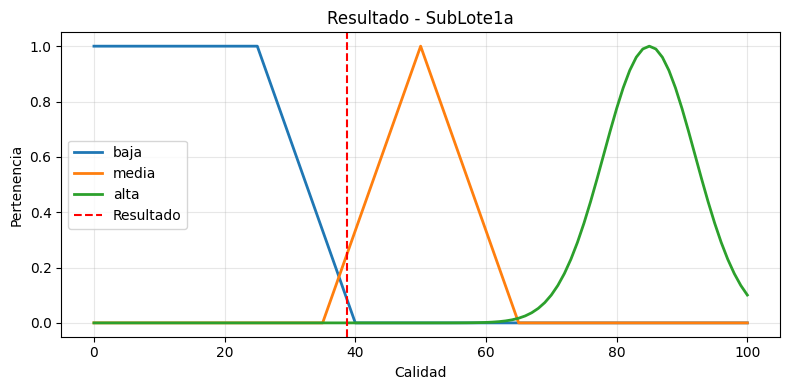

SubLote1b (Lote Lote1): H=11.0%, T=12.0mm, D=0 -> Calidad=38.73 (Baja)


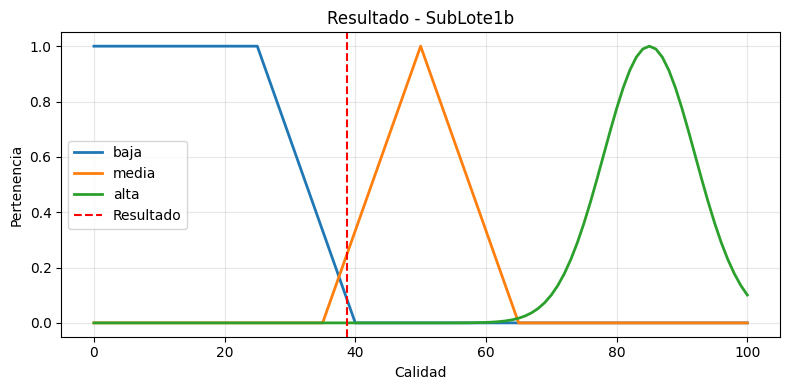

SubLote1c (Lote Lote1): H=11.0%, T=12.0mm, D=1 -> Calidad=54.26 (Media)


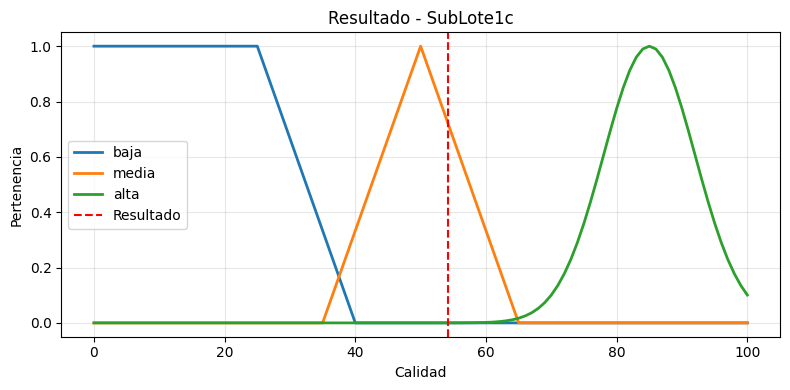

SubLote2a (Lote Lote2): H=12.0%, T=12.0mm, D=0 -> Calidad=30.11 (Baja)


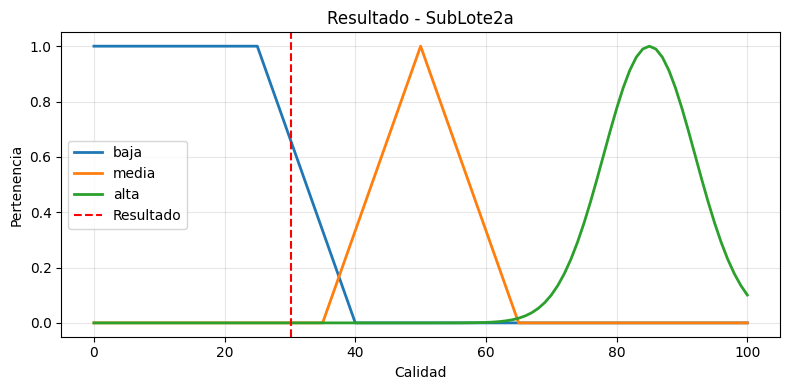

SubLote2b (Lote Lote2): H=12.0%, T=12.0mm, D=0 -> Calidad=30.11 (Baja)


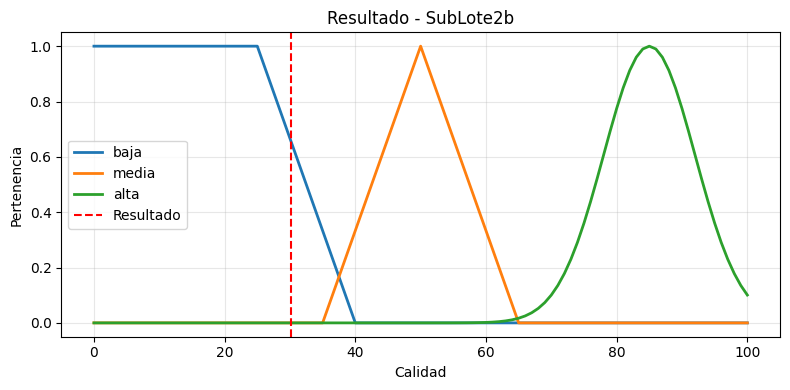

SubLote3a (Lote Lote3): H=13.0%, T=12.0mm, D=1 -> Calidad=42.97 (Media)


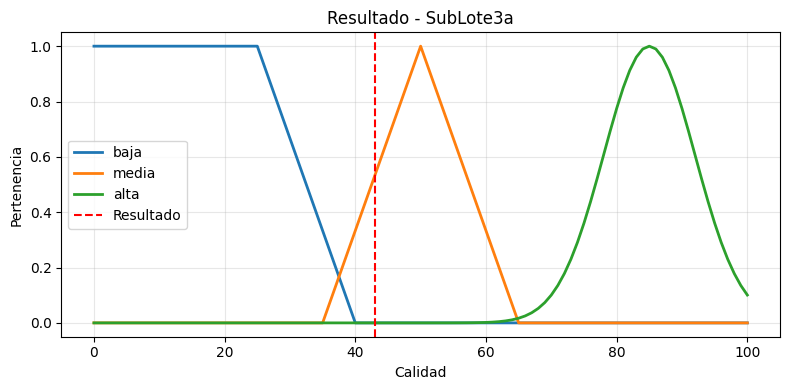

SubLote3b (Lote Lote3): H=13.0%, T=12.0mm, D=0 -> Calidad=30.11 (Baja)


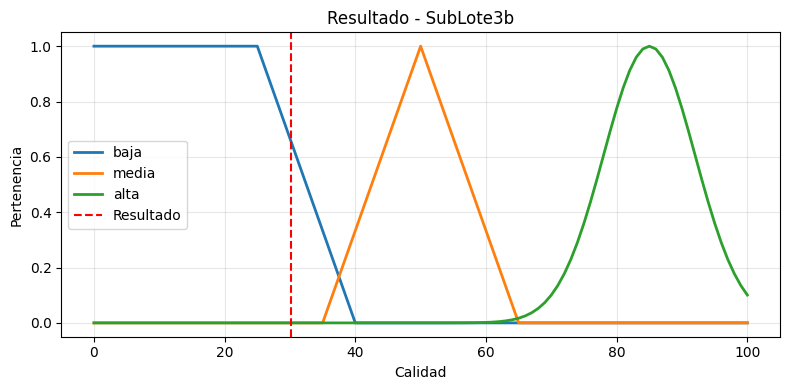

SubLote4a (Lote Lote4): H=14.0%, T=12.0mm, D=1 -> Calidad=42.97 (Media)


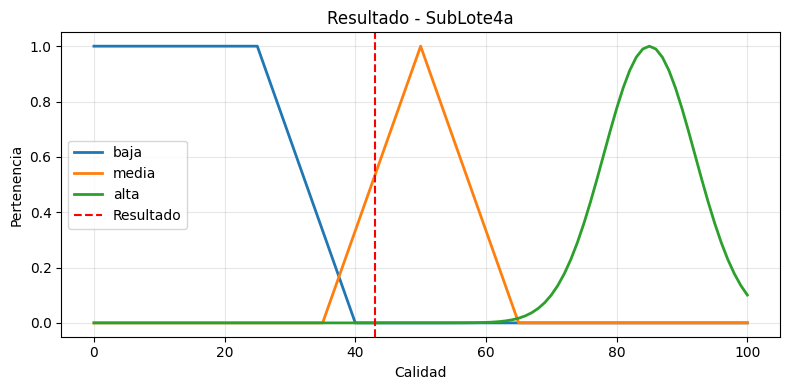

SubloteSinTipo1 (Lote Lote1): H=11.0%, T=12.0mm, D=0 -> Calidad=38.73 (Baja)


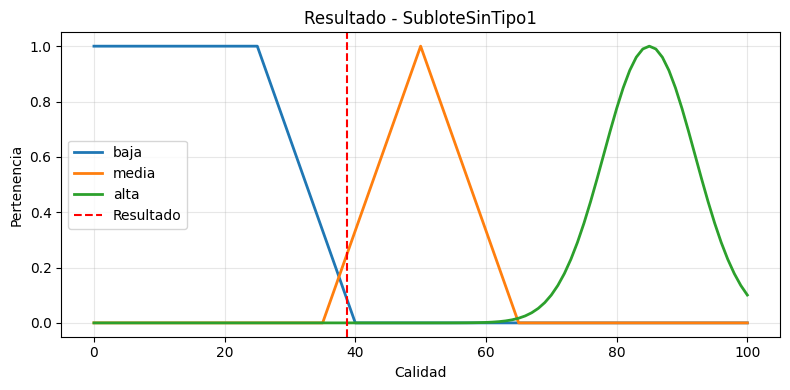

SubloteSinTipo2 (Lote None): H=12.0%, T=12.0mm, D=0 -> Calidad=30.11 (Baja)


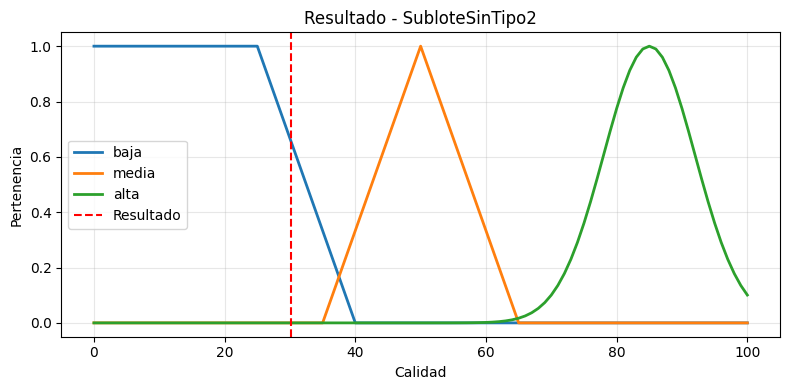

[i] Resultados difusos guardados en resultados_difusos.csv


In [ ]:

#variables difusas
humedad = ctrl.Antecedent(np.arange(8, 18.1, 0.1), 'humedad')
tamaño = ctrl.Antecedent(np.arange(5, 20.1, 0.1), 'tamaño')
defectos = ctrl.Antecedent(np.arange(0, 20.1, 0.1), 'defectos')
calidad = ctrl.Consequent(np.arange(0, 101, 1), 'calidad')

# Humedad (%)
humedad['baja'] = fuzz.trimf(humedad.universe, [8, 8, 12])
humedad['media'] = fuzz.trapmf(humedad.universe, [9, 11, 13, 15])
humedad['alta'] = fuzz.gaussmf(humedad.universe, 16, 0.8)

# Tamaño (mm)
tamaño['pequeño'] = fuzz.trimf(tamaño.universe, [5, 5, 10])
tamaño['medio'] = fuzz.trapmf(tamaño.universe, [8, 11, 14, 16])
tamaño['grande'] = fuzz.gaussmf(tamaño.universe, 18, 1.2)

# Defectos
defectos['pocos'] = fuzz.gaussmf(defectos.universe, 1.5, 1.0)
defectos['moderados'] = fuzz.trimf(defectos.universe, [3, 10, 15])
defectos['muchos'] = fuzz.trapmf(defectos.universe, [12, 15, 20, 20])

# Calidad
calidad['baja'] = fuzz.trapmf(calidad.universe, [0, 0, 25, 40])
calidad['media'] = fuzz.trimf(calidad.universe, [35, 50, 65])
calidad['alta'] = fuzz.gaussmf(calidad.universe, 85, 7)

# Modificadores
tamaño['muy_grande'] = tamaño['grande'].mf ** 2
humedad['ligeramente_baja'] = np.sqrt(humedad['baja'].mf)

#Reglas
reglas = [
    ctrl.Rule(humedad['alta'] & defectos['muchos'], calidad['baja']),
    ctrl.Rule(tamaño['grande'] & defectos['pocos'], calidad['alta']),
    ctrl.Rule(humedad['media'] & tamaño['medio'], calidad['media']),
    ctrl.Rule(~defectos['pocos'], calidad['baja']),  # complemento
    ctrl.Rule(tamaño['grande'] | humedad['baja'], calidad['media']),
    ctrl.Rule(humedad['baja'] & defectos['pocos'], calidad['alta']),
    ctrl.Rule(humedad['alta'] & tamaño['pequeño'], calidad['baja']),
    ctrl.Rule(defectos['moderados'] & humedad['media'], calidad['media']),
    ctrl.Rule(tamaño['medio'] | humedad['media'], calidad['media']),
    ctrl.Rule(tamaño['muy_grande'] & humedad['ligeramente_baja'], calidad['alta']),
]

sistema = ctrl.ControlSystem(reglas)

#Función para graficar membresías
def plot_membership(var, title, filename=None):
    plt.figure(figsize=(8, 4))
    for label in var.terms:
        plt.plot(var.universe, var[label].mf, label=label, linewidth=2)
    plt.title(f'Funciones de Pertenencia - {title}', fontsize=14)
    plt.xlabel('Valor', fontsize=12)
    plt.ylabel('Pertenencia', fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if filename:
        plt.savefig(filename)
        print(f"[i] Gráfico guardado: {filename}")
    else:
        plt.show()
    plt.close()

#Leer datos desde la ontología
def extraer_sublotes(path_ttl="ontologia_after_reasoning.ttl"):
    EX = Namespace("http://example.org/cafe#")
    g = Graph()
    g.parse(path_ttl, format="turtle")

    sublotes = []
    for s in g.subjects(RDF.type, EX.SubLote):
        nombre = s.split("#")[-1]

        # buscar lote
        lote = None
        for o in g.objects(s, EX.perteneceALote):
            lote = o.split("#")[-1]

        # humedad del lote
        humedad_val = 12.0
        if lote:
            for v in g.objects(EX[lote], EX.nivelHumedad):
                try:
                    humedad_val = float(v)
                except:
                    pass

        # contar defectos
        defectos_val = len(list(g.objects(s, EX.presentaDefecto)))

        # tamaño: si no existe, asignar valor por defecto
        tamaño_val = 12.0
        for v in g.objects(s, EX.tamañoGrano):
            try:
                tamaño_val = float(v)
                # agrega la propiedad tamañoGrano al gráfico si no existe, para que la función pueda leerla
                if (s, EX.tamañoGrano, Literal(tamaño_val, datatype=XSD.float)) not in g:
                    g.add((s, EX.tamañoGrano, Literal(tamaño_val, datatype=XSD.float)))
            except:
                pass


        sublotes.append({
            "sublote": nombre,
            "lote": lote,
            "humedad": humedad_val,
            "tamaño": tamaño_val,
            "defectos": defectos_val
        })

    return sublotes

#Evaluar cada sublote y guardar resultados en CSV
def evaluar_sublotes():
    datos = extraer_sublotes()
    resultados = [] # List to store results for CSV
    for s in datos:
        simulador = ctrl.ControlSystemSimulation(sistema)
        simulador.input['humedad'] = s['humedad']
        simulador.input['tamaño'] = s['tamaño']
        simulador.input['defectos'] = s['defectos']
        simulador.compute()

        calidad_val = simulador.output['calidad']
        categoria = "Media"
        if calidad_val >= 70:
            categoria = "Alta"
        elif calidad_val <= 40:
            categoria = "Baja"

        print(f"{s['sublote']} (Lote {s['lote']}): "
              f"H={s['humedad']}%, T={s['tamaño']}mm, D={s['defectos']} -> "
              f"Calidad={calidad_val:.2f} ({categoria})")

        # Add results to the list
        resultados.append({
            "sublote": s['sublote'],
            "calidad_score": calidad_val,
            "calidad_categoria": categoria
        })

        # Gráfica de salida
        plt.figure(figsize=(8, 4))
        for label in calidad.terms:
            plt.plot(calidad.universe, calidad[label].mf, label=label, linewidth=2)
        plt.axvline(calidad_val, color='red', linestyle='--', label='Resultado')
        plt.title(f'Resultado - {s["sublote"]}')
        plt.xlabel('Calidad')
        plt.ylabel('Pertenencia')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Save results to CSV
    df_resultados = pd.DataFrame(resultados)
    df_resultados.to_csv("resultados_difusos.csv", index=False)
    print("[i] Resultados difusos guardados en resultados_difusos.csv")


#Ejecutar
if __name__ == "__main__":
    # Prgraficar todas las funciones de pertenencia
    plot_membership(humedad, "Humedad (%)", "membresia_humedad.png")
    plot_membership(tamaño, "Tamaño (mm)", "membresia_tamaño.png")
    plot_membership(defectos, "Defectos (número)", "membresia_defectos.png")
    plot_membership(calidad, "Calidad del Café", "membresia_calidad.png")

    #evaluar cada sublote de la ontología y guardar resultados
    evaluar_sublotes()

In [ ]:
from google.colab import files
files.download("membresia_humedad.png")
files.download("membresia_tamaño.png")
files.download("membresia_defectos.png")
files.download("membresia_calidad.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Sistema Experto para la Clasificación de la Calidad del Café**

In [ ]:

EX = Namespace("http://example.org/cafe#")

#Definición de Clases de Hechos
class SubloteFact(Fact):
    """Hecho: información de un sublote"""
    pass

class LoteFact(Fact):
    """Hecho: información de un lote"""
    pass

class DefectoFact(Fact):
    """Hecho: defecto encontrado en un sublote"""
    pass

class PropiedadSensorialFact(Fact):
    """Hecho: propiedad sensorial en un sublote"""
    pass

class CalidadDifusaFact(Fact):
    """Hecho: resultado difuso para un sublote"""
    pass

class AsignacionFact(Fact):
    """Hecho: asignación final de un sublote"""
    pass

#Funciones de carga (Ontología, Sistema Difuso)
def cargar_ontologia(path="ontologia_after_reasoning.ttl"):
    g = Graph()
    g.parse(path, format="turtle")
    datos = {"sublotes": [], "lotes": {}, "defectos": [], "props": []}

    # Lotes
    for l in g.subjects(RDF.type, EX.Lote):
        nombre = l.split("#")[-1]
        humedad = 12.0
        for v in g.objects(l, EX.nivelHumedad):
            try:
                humedad = float(v)
            except:
                pass
        datos["lotes"][nombre] = humedad

    # SubLotes
    for s in g.subjects(RDF.type, EX.SubLote):
        nombre = s.split("#")[-1]
        lote = None
        for o in g.objects(s, EX.perteneceALote):
            lote = o.split("#")[-1]

        datos["sublotes"].append({"sublote": nombre, "lote": lote})

        # Defectos
        for d in g.objects(s, EX.presentaDefecto):
            datos["defectos"].append({"sublote": nombre, "defecto": d.split("#")[-1]})

        # Propiedades sensoriales
        for p in g.objects(s, EX.tieneCalidad):
            datos["props"].append({"sublote": nombre, "propiedad": p.split("#")[-1]})

    return datos

def cargar_difuso(path="resultados_difusos.csv"):
    if not Path(path).exists():
        raise FileNotFoundError("No existe resultados_difusos.csv, ejecútalo desde el sistema difuso.")
    df = pd.read_csv(path)
    return df

#Motor Experto
class SistemaCafe(KnowledgeEngine):

    # Reglas de Alta prioridad
    @Rule(CalidadDifusaFact(categoria='Baja'), salience=96)
    def descarte_calidad_baja(self):
        msg = "Destino: Descarte | Motivo: Calidad baja"
        print(msg)
        self.declare(AsignacionFact(destino="Descarte", motivo="Calidad baja"))

    @Rule(CalidadDifusaFact(categoria='Alta'), salience=90)
    def exportacion_calidad_alta(self):
        msg = "Destino: Exportación | Motivo: Calidad alta"
        print(msg)
        self.declare(AsignacionFact(destino="Exportacion", motivo="Calidad alta"))

    @Rule(DefectoFact(defecto='Moho'), salience=83)
    def descarte_moho(self):
        msg = "Destino: Descarte | Motivo: Defecto Moho"
        print(msg)
        self.declare(AsignacionFact(destino="Descarte", motivo="Defecto Moho"))

    @Rule(DefectoFact(defecto='Broca') & CalidadDifusaFact(score=MATCH.s), salience=72)
    def broca_regla(self, s):
        if s > 70:
            msg = "Destino: Retener | Motivo: Broca con calidad aceptable"
            print(msg)
            self.declare(AsignacionFact(destino="Retener", motivo="Broca con calidad aceptable"))
        else:
            msg = "Destino: Descarte | Motivo: Broca con baja calidad"
            print(msg)
            self.declare(AsignacionFact(destino="Descarte", motivo="Broca con baja calidad"))

    # Reglas de Media prioridad
    @Rule(CalidadDifusaFact(categoria='Media') & ~DefectoFact(defecto='Moho'), salience=50)
    def nacional_media(self):
        msg = "Destino: Nacional | Motivo: Calidad media"
        print(msg)
        self.declare(AsignacionFact(destino="Nacional", motivo="Calidad media"))

    @Rule(PropiedadSensorialFact(propiedad='AltoAroma') & CalidadDifusaFact(categoria='Alta'), salience=62)
    def exportacion_altoaroma(self):
        msg = "Destino: Exportación | Motivo: Alto Aroma + Alta calidad"
        print(msg)
        self.declare(AsignacionFact(destino="Exportacion", motivo="Alto Aroma + Alta calidad"))

    @Rule(PropiedadSensorialFact(propiedad='BajoCuerpo') & CalidadDifusaFact(categoria='Media'), salience=57)
    def retener_bajocuerpo(self):
        msg = "Destino: Retener | Motivo: Calidad media con Bajo Cuerpo"
        print(msg)
        self.declare(AsignacionFact(destino="Retener", motivo="Calidad media con Bajo Cuerpo"))

    # Reglas de Baja prioridad
    @Rule(CalidadDifusaFact(score=P(lambda x: x < 30)), salience=32)
    def descarte_score_bajo(self):
        msg = "Destino: Descarte | Motivo: Score difuso < 30"
        print(msg)
        self.declare(AsignacionFact(destino="Descarte", motivo="Score difuso < 30"))

    @Rule(CalidadDifusaFact(score=P(lambda x: x > 85)), salience=25)
    def exportacion_score_alto(self):
        msg = "Destino: Exportación | Motivo: Score difuso > 85"
        print(msg)
        self.declare(AsignacionFact(destino="Exportacion", motivo="Score difuso > 85"))

    @Rule(SubloteFact(), NOT(AsignacionFact()), salience=14)
    def asignacion_por_defecto(self):
        msg = "Destino: Nacional | Motivo: Asignación por defecto"
        print(msg)
        self.declare(AsignacionFact(destino="Nacional", motivo="Asignación por defecto"))

#Ejecutar
if __name__ == "__main__":
    engine = SistemaCafe()

    #Base de hechos
    print("\nESCENARIO 1: Alta calidad sin defectos")
    engine.reset()
    engine.declare(SubloteFact(sublote="S1", lote="Lote1"))
    engine.declare(CalidadDifusaFact(sublote="S1", score=90, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 2: Defecto Moho y calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S2", lote="Lote2"))
    engine.declare(DefectoFact(sublote="S2", defecto="Moho"))
    engine.declare(CalidadDifusaFact(sublote="S2", score=60, categoria="Media"))
    engine.run()

    print("\nESCENARIO 3: Defecto Broca y calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S3", lote="Lote3"))
    engine.declare(DefectoFact(sublote="S3", defecto="Broca"))
    engine.declare(CalidadDifusaFact(sublote="S3", score=20, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 4: Propiedad Alto Aroma y calidad alta")
    engine.reset()
    engine.declare(SubloteFact(sublote="S4", lote="Lote1"))
    engine.declare(PropiedadSensorialFact(sublote="S4", propiedad="AltoAroma"))
    engine.declare(CalidadDifusaFact(sublote="S4", score=85, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 5: Bajo Cuerpo y calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S5", lote="Lote2"))
    engine.declare(PropiedadSensorialFact(sublote="S5", propiedad="BajoCuerpo"))
    engine.declare(CalidadDifusaFact(sublote="S5", score=55, categoria="Media"))
    engine.run()

    print("\nESCENARIO 6: Alta calidad con score > 85")
    engine.reset()
    engine.declare(SubloteFact(sublote="S6", lote="Lote3"))
    engine.declare(CalidadDifusaFact(sublote="S6", score=95, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 7: Calidad baja con score < 30")
    engine.reset()
    engine.declare(SubloteFact(sublote="S7", lote="Lote1"))
    engine.declare(CalidadDifusaFact(sublote="S7", score=25, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 8: Calidad media sin defectos")
    engine.reset()
    engine.declare(SubloteFact(sublote="S8", lote="Lote2"))
    engine.declare(CalidadDifusaFact(sublote="S8", score=65, categoria="Media"))
    engine.run()

    print("\nESCENARIO 9: Broca con buena calidad")
    engine.reset()
    engine.declare(SubloteFact(sublote="S9", lote="Lote3"))
    engine.declare(DefectoFact(sublote="S9", defecto="Broca"))
    engine.declare(CalidadDifusaFact(sublote="S9", score=75, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 10: Moho con calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S10", lote="Lote1"))
    engine.declare(DefectoFact(sublote="S10", defecto="Moho"))
    engine.declare(CalidadDifusaFact(sublote="S10", score=15, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 11: Sin defectos, calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S11", lote="Lote2"))
    engine.declare(CalidadDifusaFact(sublote="S11", score=50, categoria="Media"))
    engine.run()

    print("\nESCENARIO 12: Alto Aroma con calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S12", lote="Lote3"))
    engine.declare(PropiedadSensorialFact(sublote="S12", propiedad="AltoAroma"))
    engine.declare(CalidadDifusaFact(sublote="S12", score=70, categoria="Media"))
    engine.run()

    print("\nESCENARIO 13: Broca con calidad alta")
    engine.reset()
    engine.declare(SubloteFact(sublote="S13", lote="Lote1"))
    engine.declare(DefectoFact(sublote="S13", defecto="Broca"))
    engine.declare(CalidadDifusaFact(sublote="S13", score=80, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 14: Bajo Cuerpo con calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S14", lote="Lote2"))
    engine.declare(PropiedadSensorialFact(sublote="S14", propiedad="BajoCuerpo"))
    engine.declare(CalidadDifusaFact(sublote="S14", score=35, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 15: Moho con calidad alta (conflicto)")
    engine.reset()
    engine.declare(SubloteFact(sublote="S15", lote="Lote3"))
    engine.declare(DefectoFact(sublote="S15", defecto="Moho"))
    engine.declare(CalidadDifusaFact(sublote="S15", score=90, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 16: Sin defectos, calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S16", lote="Lote1"))
    engine.declare(CalidadDifusaFact(sublote="S16", score=28, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 17: Alto Aroma con calidad alta")
    engine.reset()
    engine.declare(SubloteFact(sublote="S17", lote="Lote2"))
    engine.declare(PropiedadSensorialFact(sublote="S17", propiedad="AltoAroma"))
    engine.declare(CalidadDifusaFact(sublote="S17", score=88, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 18: Bajo Cuerpo con calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S18", lote="Lote3"))
    engine.declare(PropiedadSensorialFact(sublote="S18", propiedad="BajoCuerpo"))
    engine.declare(CalidadDifusaFact(sublote="S18", score=60, categoria="Media"))
    engine.run()

    print("\nESCENARIO 19: Broca con calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S19", lote="Lote1"))
    engine.declare(DefectoFact(sublote="S19", defecto="Broca"))
    engine.declare(CalidadDifusaFact(sublote="S19", score=22, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 20: Moho con calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S20", lote="Lote2"))
    engine.declare(DefectoFact(sublote="S20", defecto="Moho"))
    engine.declare(CalidadDifusaFact(sublote="S20", score=55, categoria="Media"))
    engine.run()

    print("\nESCENARIO 21: Sin defectos, calidad alta")
    engine.reset()
    engine.declare(SubloteFact(sublote="S21", lote="Lote3"))
    engine.declare(CalidadDifusaFact(sublote="S21", score=92, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 22: Bajo Cuerpo con calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S22", lote="Lote1"))
    engine.declare(PropiedadSensorialFact(sublote="S22", propiedad="BajoCuerpo"))
    engine.declare(CalidadDifusaFact(sublote="S22", score=30, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 23: Broca con calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S23", lote="Lote2"))
    engine.declare(DefectoFact(sublote="S23", defecto="Broca"))
    engine.declare(CalidadDifusaFact(sublote="S23", score=65, categoria="Media"))
    engine.run()

    print("\nESCENARIO 24: Moho con calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S24", lote="Lote3"))
    engine.declare(DefectoFact(sublote="S24", defecto="Moho"))
    engine.declare(CalidadDifusaFact(sublote="S24", score=18, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 25: Alto Aroma con calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S25", lote="Lote1"))
    engine.declare(PropiedadSensorialFact(sublote="S25", propiedad="AltoAroma"))
    engine.declare(CalidadDifusaFact(sublote="S25", score=68, categoria="Media"))
    engine.run()

    print("\nESCENARIO 26: Bajo Cuerpo con calidad alta")
    engine.reset()
    engine.declare(SubloteFact(sublote="S26", lote="Lote2"))
    engine.declare(PropiedadSensorialFact(sublote="S26", propiedad="BajoCuerpo"))
    engine.declare(CalidadDifusaFact(sublote="S26", score=82, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 27: Sin defectos, calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S27", lote="Lote3"))
    engine.declare(CalidadDifusaFact(sublote="S27", score=20, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 28: Broca con calidad alta")
    engine.reset()
    engine.declare(SubloteFact(sublote="S28", lote="Lote1"))
    engine.declare(DefectoFact(sublote="S28", defecto="Broca"))
    engine.declare(CalidadDifusaFact(sublote="S28", score=88, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 29: Moho con calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S29", lote="Lote2"))
    engine.declare(DefectoFact(sublote="S29", defecto="Moho"))
    engine.declare(CalidadDifusaFact(sublote="S29", score=50, categoria="Media"))
    engine.run()

    print("\nESCENARIO 30: Alto Aroma con calidad alta")
    engine.reset()
    engine.declare(SubloteFact(sublote="S30", lote="Lote3"))
    engine.declare(PropiedadSensorialFact(sublote="S30", propiedad="AltoAroma"))
    engine.declare(CalidadDifusaFact(sublote="S30", score=90, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 31: Sin defectos, calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S31", lote="Lote1"))
    engine.declare(CalidadDifusaFact(sublote="S31", score=60, categoria="Media"))
    engine.run()

    print("\nESCENARIO 32: Bajo Cuerpo con calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S32", lote="Lote2"))
    engine.declare(PropiedadSensorialFact(sublote="S32", propiedad="BajoCuerpo"))
    engine.declare(CalidadDifusaFact(sublote="S32", score=25, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 33: Broca con calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S33", lote="Lote3"))
    engine.declare(DefectoFact(sublote="S33", defecto="Broca"))
    engine.declare(CalidadDifusaFact(sublote="S33", score=28, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 34: Moho con calidad alta")
    engine.reset()
    engine.declare(SubloteFact(sublote="S34", lote="Lote1"))
    engine.declare(DefectoFact(sublote="S34", defecto="Moho"))
    engine.declare(CalidadDifusaFact(sublote="S34", score=87, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 35: Alto Aroma con calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S35", lote="Lote2"))
    engine.declare(PropiedadSensorialFact(sublote="S35", propiedad="AltoAroma"))
    engine.declare(CalidadDifusaFact(sublote="S35", score=30, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 36: Bajo Cuerpo con calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S36", lote="Lote3"))
    engine.declare(PropiedadSensorialFact(sublote="S36", propiedad="BajoCuerpo"))
    engine.declare(CalidadDifusaFact(sublote="S36", score=65, categoria="Media"))
    engine.run()

    print("\nESCENARIO 37: Sin defectos, calidad alta")
    engine.reset()
    engine.declare(SubloteFact(sublote="S37", lote="Lote1"))
    engine.declare(CalidadDifusaFact(sublote="S37", score=93, categoria="Alta"))
    engine.run()

    print("\nESCENARIO 38: Broca con calidad media")
    engine.reset()
    engine.declare(SubloteFact(sublote="S38", lote="Lote2"))
    engine.declare(DefectoFact(sublote="S38", defecto="Broca"))
    engine.declare(CalidadDifusaFact(sublote="S38", score=55, categoria="Media"))
    engine.run()

    print("\nESCENARIO 39: Moho con calidad baja")
    engine.reset()
    engine.declare(SubloteFact(sublote="S39", lote="Lote3"))
    engine.declare(DefectoFact(sublote="S39", defecto="Moho"))
    engine.declare(CalidadDifusaFact(sublote="S39", score=10, categoria="Baja"))
    engine.run()

    print("\nESCENARIO 40: Alto Aroma con calidad alta")
    engine.reset()
    engine.declare(SubloteFact(sublote="S40", lote="Lote1"))
    engine.declare(PropiedadSensorialFact(sublote="S40", propiedad="AltoAroma"))
    engine.declare(CalidadDifusaFact(sublote="S40", score=89, categoria="Alta"))
    engine.run()



ESCENARIO 1: Alta calidad sin defectos
Destino: Exportación | Motivo: Calidad alta
Destino: Exportación | Motivo: Score difuso > 85

ESCENARIO 2: Defecto Moho y calidad media
Destino: Descarte | Motivo: Defecto Moho

ESCENARIO 3: Defecto Broca y calidad baja
Destino: Descarte | Motivo: Calidad baja
Destino: Descarte | Motivo: Broca con baja calidad
Destino: Descarte | Motivo: Score difuso < 30

ESCENARIO 4: Propiedad Alto Aroma y calidad alta
Destino: Exportación | Motivo: Calidad alta
Destino: Exportación | Motivo: Alto Aroma + Alta calidad

ESCENARIO 5: Bajo Cuerpo y calidad media
Destino: Retener | Motivo: Calidad media con Bajo Cuerpo
Destino: Nacional | Motivo: Calidad media

ESCENARIO 6: Alta calidad con score > 85
Destino: Exportación | Motivo: Calidad alta
Destino: Exportación | Motivo: Score difuso > 85

ESCENARIO 7: Calidad baja con score < 30
Destino: Descarte | Motivo: Calidad baja
Destino: Descarte | Motivo: Score difuso < 30

ESCENARIO 8: Calidad media sin defectos
Desti